In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ot
from matplotlib import animation

In [2]:
def sersic(n, Ie, re, r):
    bn = 2*n - 1/3
    return Ie * np.exp(-bn*((r/re)**(1/n)-1))

def prob_sersic(n, Ie, re, r):
    return sersic(n, Ie, re, r) * 2*np.pi*r


def spiral(n, Ie, re, Na, w, p, r, phi):
    return sersic(n, Ie, re, r) * (1 + w*np.sin(Na/np.tan(p) * np.log10(r) - Na*phi))

def prob_spiral(n, Ie, re, Na, w, p, r, phi):
    return spiral(n, Ie, re, Na, w, p, r, phi) * r

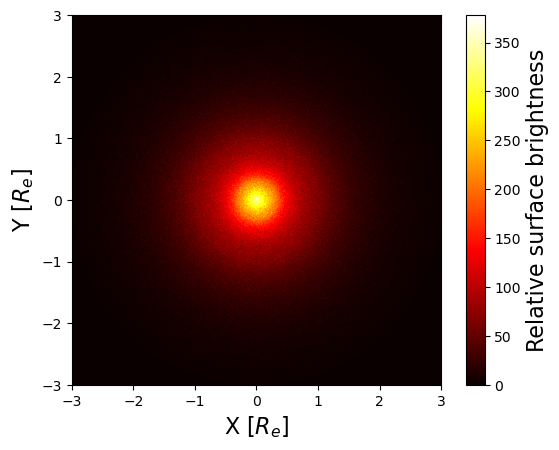

In [46]:
#Disky galaxy
import matplotlib as mpl
mpl.rc('axes', labelsize=16)
n_sersic = 1; re = 2; Ie = 1; rmax = 3*re
N = 5000000

#Draw random samples of radius and probability
r = np.random.uniform(0,rmax,5*N)
pr = np.random.uniform(0,prob_sersic(n_sersic, Ie, re, re),5*N)

#Accept/Reject method
mask = pr <= prob_sersic(n_sersic, Ie, re, r)
r = (r[mask])[:N]

#Spread out in a 2D disk
theta = np.random.uniform(0,2*np.pi,N)
rx = r * np.cos(theta) / re
ry = r * np.sin(theta) / re
x1 = np.histogram2d(rx, ry, bins=500)[0]
plt.imshow(x1, cmap='hot', extent=(-rmax/re,rmax/re,-rmax/re,rmax/re))
plt.xlabel(r"X [$R_e$]")
plt.ylabel(r"Y [$R_e$]")
plt.colorbar(label="Relative surface brightness")
plt.savefig("Disc galaxy")

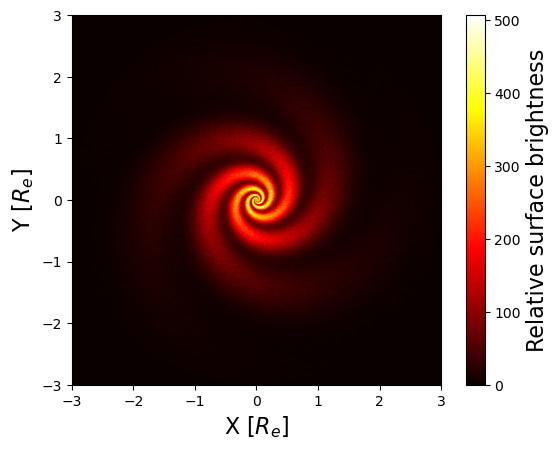

In [47]:
#Spiral arm galaxy
mpl.rc('axes', labelsize=16)
n_sersic = 1; re = 2; Ie = 1; rmax = 3*re; Na = 3; w = 0.6; p = 10*np.pi/180
N = 5000000

#Now both radius and phi dependence
r = np.random.uniform(0,rmax,5*N)
phi = np.random.uniform(0,2*np.pi,5*N)
pr = np.random.uniform(0,np.max(prob_spiral(n_sersic, Ie, re, Na, w, p, r, phi)),5*N)

mask = pr <= prob_spiral(n_sersic, Ie, re, Na, w, p, r, phi)
r = (r[mask])[:N]
phi = (phi[mask])[:N]

rx = r*np.cos(phi) / re
ry = r*np.sin(phi) / re

x2 = np.histogram2d(rx, ry, bins=500)[0]
plt.imshow(x2, cmap='hot', extent=(-rmax/re,rmax/re,-rmax/re,rmax/re))
plt.xlabel(r"X [$R_e$]")
plt.ylabel(r"Y [$R_e$]")
plt.colorbar(label="Relative surface brightness")
plt.savefig("Spiral galaxy")

In [ ]:
A = np.array([x1, x2])
reg =0.0001
weights=[np.array((0.25, 0.75)), np.array((0.5, 0.5)), np.array((0.75, 0.25))]
X1 = ot.bregman.convolutional_barycenter2d(A, reg, weights[1], numItermax = 20000, verbose=True)
X2 = ot.bregman.convolutional_barycenter2d(A, reg, weights[2], numItermax = 20000, verbose=True)

    9|3.612269e+05|
   19|2.293281e+05|
   29|1.667897e+05|
   39|1.303743e+05|
   49|1.070166e+05|
   59|9.109229e+04|
   69|7.973093e+04|
   79|7.132279e+04|
   89|6.489945e+04|
   99|5.984674e+04|
  109|5.575930e+04|
  119|5.236004e+04|
  129|4.943207e+04|
  139|4.684188e+04|
  149|4.451117e+04|
  159|4.238833e+04|
  169|4.043797e+04|
  179|3.863246e+04|
  189|3.694912e+04|
  199|3.537066e+04|
  209|3.388338e+04|
  219|3.247633e+04|
  229|3.114121e+04|
  239|2.987148e+04|
  249|2.866201e+04|
  259|2.750860e+04|
  269|2.640783e+04|
  279|2.535692e+04|
  289|2.435345e+04|
  299|2.339532e+04|
  309|2.248070e+04|
  319|2.160800e+04|
  329|2.077584e+04|
  339|1.998335e+04|
  349|1.922942e+04|
  359|1.851210e+04|
  369|1.782970e+04|
  379|1.718065e+04|
  389|1.656363e+04|
  399|1.597799e+04|
  409|1.542138e+04|
  419|1.489155e+04|
  429|1.438584e+04|
  439|1.390183e+04|
  449|1.343679e+04|
  459|1.298838e+04|
  469|1.255562e+04|
  479|1.213796e+04|
  489|1.173485e+04|
  499|1.134577e+04|


IndexError: list index out of range

In [39]:
X0 = ot.bregman.convolutional_barycenter2d(A, reg, weights[0], numItermax = 20000, verbose=True)

    9|3.613575e+05|
   19|2.295003e+05|
   29|1.669491e+05|
   39|1.304942e+05|
   49|1.071074e+05|
   59|9.116142e+04|
   69|7.978375e+04|
   79|7.136296e+04|
   89|6.492989e+04|
   99|5.986923e+04|
  109|5.577557e+04|
  119|5.237149e+04|
  129|4.943952e+04|
  139|4.684594e+04|
  149|4.451225e+04|
  159|4.238681e+04|
  169|4.043419e+04|
  179|3.862680e+04|
  189|3.694195e+04|
  199|3.536222e+04|
  209|3.387398e+04|
  219|3.246613e+04|
  229|3.113039e+04|
  239|2.986018e+04|
  249|2.865029e+04|
  259|2.749651e+04|
  269|2.639551e+04|
  279|2.534437e+04|
  289|2.434072e+04|
  299|2.338243e+04|
  309|2.246768e+04|
  319|2.159486e+04|
  329|2.076258e+04|
  339|1.996992e+04|
  349|1.921585e+04|
  359|1.849840e+04|
  369|1.781589e+04|
  379|1.716673e+04|
  389|1.654958e+04|
  399|1.596380e+04|
  409|1.540714e+04|
  419|1.487728e+04|
  429|1.437167e+04|
  439|1.388782e+04|
  449|1.342307e+04|
  459|1.297502e+04|
  469|1.254261e+04|
  479|1.212528e+04|
  489|1.172251e+04|
  499|1.133377e+04|


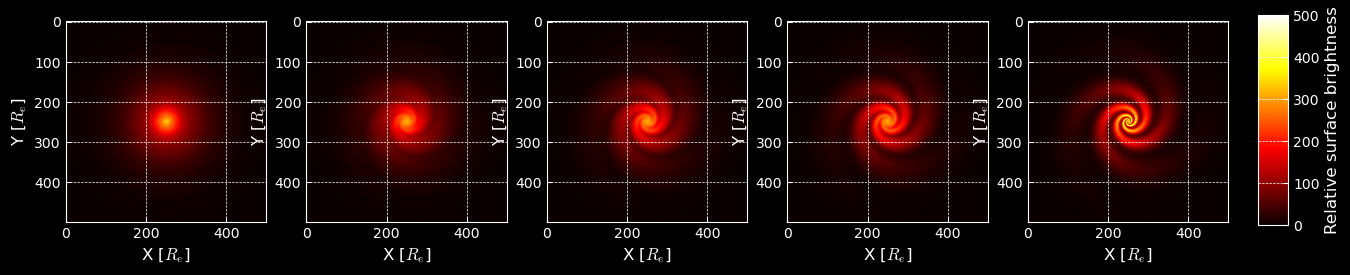

In [ ]:
plt.style.use('dark_background')
fig, ax = plt.subplots(1,5, figsize=(15,3))
norm = plt.cm.colors.LogNorm()
ax[0].imshow(x1, cmap='hot', vmin=0, vmax=500)
ax[1].imshow(X2, cmap='hot', vmin=0, vmax=500)
ax[2].imshow(X1, cmap='hot', vmin=0, vmax=500)
ax[3].imshow(X0, cmap='hot', vmin=0, vmax=500)
test = ax[4].imshow(x2, cmap='hot', vmin=0, vmax=500)
cbar_ax = fig.add_axes([0.92,0.15,0.02,0.7])
fig.colorbar(test, cax=cbar_ax, label="Relative surface brightness")
for a in ax:
    a.set_facecolor('black')
plt.setp(ax.flat, xlabel=r"X [$R_e$]", ylabel=r"Y [$R_e$]")
plt.show()

In [79]:
np.savetxt("Initial galaxy.txt",x1)
np.savetxt("alpha=0.25.txt", X0)
np.savetxt("alpha=0.5.txt", X1)
np.savetxt("alpha=0.75.txt", X2)
np.savetxt("Final galaxy.txt",x2)

In [10]:
A = np.array([x1, x2])
reg =0.0001
# Interpolation animation
alphas = np.round(np.linspace(0.01,1,101),2)                #Alphas to use

weights = [np.array([1-alpha, alpha]) for alpha in alphas]    #Distribution weights

barycenters = [ot.bregman.convolutional_barycenter2d(A, reg, weight, verbose=True) for weight in weights]

    9|3.599706e+05|
   19|2.278494e+05|
   29|1.653110e+05|
   39|1.290864e+05|
   49|1.058292e+05|
   59|8.993951e+04|
   69|7.858234e+04|
   79|7.016117e+04|
   89|6.372136e+04|
   99|5.865892e+04|
  109|5.457877e+04|
  119|5.119155e+04|
  129|4.828297e+04|
  139|4.572586e+04|
  149|4.343781e+04|
  159|4.136221e+04|
  169|3.945860e+04|
  179|3.769876e+04|
  189|3.606028e+04|
  199|3.452407e+04|
  209|3.307628e+04|
  219|3.170716e+04|
  229|3.040836e+04|
  239|2.917354e+04|
  249|2.799745e+04|
  259|2.687577e+04|
  269|2.580559e+04|
  279|2.478411e+04|
  289|2.380895e+04|
  299|2.287827e+04|
  309|2.199029e+04|
  319|2.114319e+04|
  329|2.033525e+04|
  339|1.956471e+04|
  349|1.882997e+04|
  359|1.812926e+04|
  369|1.746085e+04|
  379|1.682302e+04|
  389|1.621385e+04|
  399|1.563075e+04|
  409|1.507258e+04|
  419|1.453864e+04|
  429|1.402839e+04|
  439|1.354196e+04|
  449|1.307917e+04|
  459|1.263828e+04|
  469|1.221646e+04|
  479|1.181108e+04|
  489|1.142000e+04|
  499|1.104263e+04|


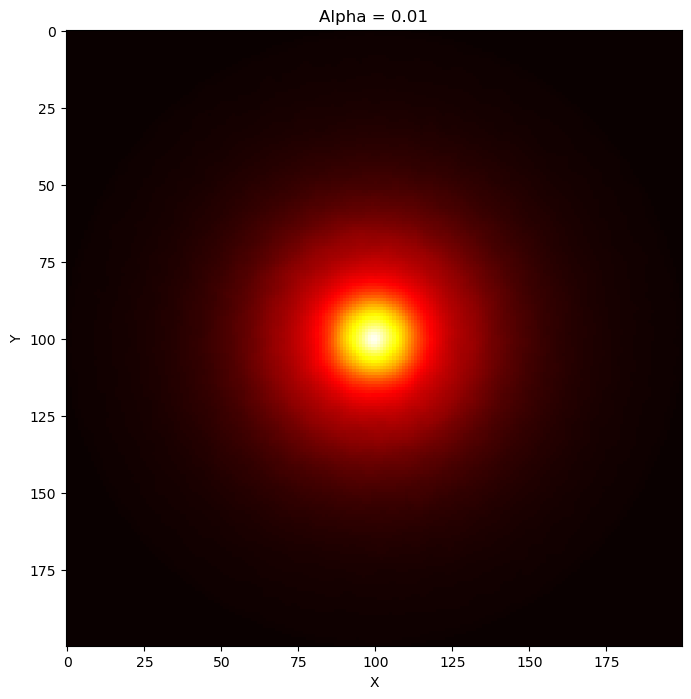

In [24]:
fig = plt.figure(figsize=(8, 8))

def animate(i):
    plt.clf()
    X = barycenters[i]
    plt.imshow(X, cmap='hot', vmax = 2000)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Alpha = "+str(alphas[i]))

anim = animation.FuncAnimation(fig, animate, frames=101, repeat=False)
anim.save("Galaxy_evolution_itp.gif", writer='pillow', fps=10)

In [38]:
reg = 0.0001
X0 = ot.bregman.convolutional_barycenter2d(A, reg, np.array((0.1,0.9)), numItermax = 20000, verbose=True)

    9|3.608709e+05|
   19|2.287336e+05|
   29|1.660648e+05|
   39|1.296330e+05|
   49|1.062381e+05|
   59|9.025289e+04|
   69|7.882297e+04|
   79|7.034717e+04|
   89|6.386637e+04|
   99|5.877057e+04|
  109|5.466506e+04|
  119|5.125753e+04|
  129|4.833235e+04|
  139|4.576011e+04|
  149|4.345919e+04|
  159|4.137109e+04|
  169|3.945740e+04|
  179|3.768833e+04|
  189|3.604271e+04|
  199|3.450046e+04|
  209|3.304830e+04|
  219|3.167559e+04|
  229|3.037386e+04|
  239|2.913633e+04|
  249|2.795793e+04|
  259|2.683439e+04|
  269|2.576278e+04|
  279|2.474010e+04|
  289|2.376393e+04|
  299|2.283237e+04|
  309|2.194363e+04|
  319|2.109582e+04|
  329|2.028721e+04|
  339|1.951613e+04|
  349|1.878089e+04|
  359|1.807981e+04|
  369|1.741112e+04|
  379|1.677307e+04|
  389|1.616395e+04|
  399|1.558113e+04|
  409|1.502322e+04|
  419|1.448946e+04|
  429|1.397925e+04|
  439|1.349252e+04|
  449|1.302930e+04|
  459|1.258840e+04|
  469|1.216695e+04|
  479|1.176251e+04|
  489|1.137248e+04|
  499|1.099615e+04|


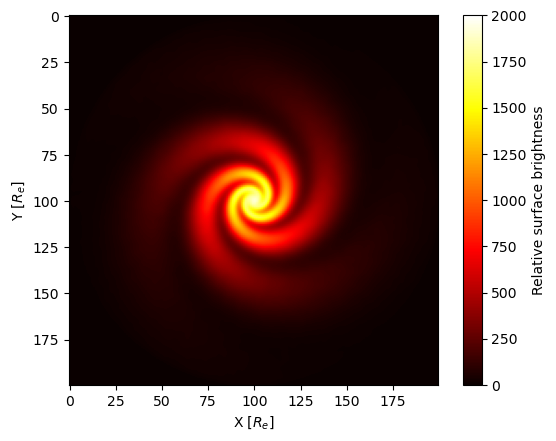

In [39]:

plt.imshow(X0, cmap='hot', vmax = 2000)
plt.xlabel(r"X [$R_e$]")
plt.ylabel(r"Y [$R_e$]")
plt.colorbar(label="Relative surface brightness")
plt.savefig("low_reg")

